# 03 — Hybrid Search: BM25 + Dense kNN

**From the AWS slide deck:** _"Hybrid search = Best of Both Worlds. BM25 + Semantic in parallel, score normalization, state-of-the-art today."_

## What this notebook demonstrates
| Method | Description |
|--------|-------------|
| Keyword (BM25) | Fast term matching — fails on synonyms/paraphrases |
| Semantic (dense kNN) | Meaning-based — fails on exact codes/jargon |
| Hybrid — Arithmetic Mean | Equal-weight blend of normalized scores |
| Hybrid — Weighted Sum | Tunable α·semantic + (1−α)·keyword |
| Hybrid — RRF | Reciprocal Rank Fusion — parameter-free, robust |

## Stack
- **Embeddings**: Amazon Bedrock `amazon.titan-embed-text-v2:0` (1024-dim)
- **Vector DB**: Qdrant (Cloud → in-memory fallback)
- **Keyword index**: `rank_bm25` BM25Okapi
- **Visualization**: matplotlib dark theme

## Step 1 — Install & Import

In [1]:
import subprocess, sys
packages = ["boto3", "qdrant-client", "rank_bm25", "numpy", "matplotlib", "python-dotenv"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)
print("Packages ready.")

Packages ready.


In [2]:
from dotenv import load_dotenv
load_dotenv('../../../.env')

import os, json, time, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import List, Dict, Tuple

import boto3
from rank_bm25 import BM25Okapi
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct, ScoredPoint

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1a1d27", "axes.edgecolor": "#3a3d4d",
    "axes.labelcolor": "#e0e0e0", "xtick.color": "#a0a0b0",
    "ytick.color": "#a0a0b0", "text.color": "#e0e0e0",
    "grid.color": "#2a2d3d", "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.family": "DejaVu Sans", "axes.titlesize": 12, "axes.labelsize": 10,
})
print("Imports OK")

Imports OK


## Step 2 — Configuration & Helpers

In [3]:
AWS_REGION      = os.getenv("AWS_DEFAULT_REGION", "us-east-1")
EMBEDDING_MODEL = "amazon.titan-embed-text-v2:0"
EMBEDDING_DIM   = 1024
QDRANT_URL      = os.getenv("QDRANT_URL", "")
QDRANT_API_KEY  = os.getenv("QDRANT_API_KEY", "")
COLLECTION      = "hybrid_search_demo"

bedrock_rt = boto3.client("bedrock-runtime", region_name=AWS_REGION)

def embed(text: str) -> np.ndarray:
    body = json.dumps({"inputText": text, "dimensions": EMBEDDING_DIM, "normalize": True})
    resp = bedrock_rt.invoke_model(
        modelId=EMBEDDING_MODEL, body=body,
        contentType="application/json", accept="application/json"
    )
    return np.array(json.loads(resp["body"].read())["embedding"], dtype=np.float32)

def embed_batch(texts: List[str], delay: float = 0.05) -> np.ndarray:
    vecs = []
    for i, t in enumerate(texts):
        vecs.append(embed(t))
        time.sleep(delay)
        if (i+1) % 10 == 0:
            print(f"  Embedded {i+1}/{len(texts)}")
    return np.vstack(vecs)

# Qdrant client
if QDRANT_URL:
    kw = {"url": QDRANT_URL}
    if QDRANT_API_KEY: kw["api_key"] = QDRANT_API_KEY
    qc = QdrantClient(**kw)
    print(f"Qdrant Cloud: {QDRANT_URL}")
else:
    qc = QdrantClient(":memory:")
    print("Qdrant in-memory")

v = embed("test")
print(f"Embedding OK — dim={v.shape[0]}, norm={np.linalg.norm(v):.4f}")

Qdrant in-memory


Embedding OK — dim=1024, norm=1.0000


## Step 3 — Movie Corpus (30 documents)

In [4]:
CORPUS = [
    {"id": 0,  "title": "The Shawshank Redemption", "year": 1994, "genre": "Drama",
     "description": "A banker convicted of murder befriends a fellow prisoner and finds redemption through acts of decency in a corrupt prison."},
    {"id": 1,  "title": "The Godfather", "year": 1972, "genre": "Crime",
     "description": "The aging patriarch of an organized crime dynasty transfers control of his empire to his reluctant son."},
    {"id": 2,  "title": "The Dark Knight", "year": 2008, "genre": "Action",
     "description": "Batman faces the Joker, a criminal mastermind who plunges Gotham City into anarchy and chaos."},
    {"id": 3,  "title": "Schindler's List", "year": 1993, "genre": "Drama",
     "description": "In German-occupied Poland, industrialist Oskar Schindler saves Jewish refugees from the Holocaust by employing them."},
    {"id": 4,  "title": "Pulp Fiction", "year": 1994, "genre": "Crime",
     "description": "Interweaving tales of crime, redemption, and violence involving hitmen, gangsters, and a boxer in Los Angeles."},
    {"id": 5,  "title": "Forrest Gump", "year": 1994, "genre": "Drama",
     "description": "The life story of an Alabama man with low intelligence who inadvertently influences major historical events."},
    {"id": 6,  "title": "Inception", "year": 2010, "genre": "Sci-Fi",
     "description": "A thief who enters people's dreams to steal secrets is offered a chance to have his criminal record erased."},
    {"id": 7,  "title": "The Matrix", "year": 1999, "genre": "Sci-Fi",
     "description": "A computer programmer discovers that reality is a simulation and joins a rebellion against machine overlords."},
    {"id": 8,  "title": "Good Will Hunting", "year": 1997, "genre": "Drama",
     "description": "A gifted janitor at MIT solves complex math problems but struggles with emotional trauma until a therapist helps him."},
    {"id": 9,  "title": "Interstellar", "year": 2014, "genre": "Sci-Fi",
     "description": "Astronauts travel through a wormhole near Saturn searching for a new habitable planet as Earth faces extinction."},
    {"id": 10, "title": "The Lion King", "year": 1994, "genre": "Animation",
     "description": "A lion cub flees after his father is murdered by his uncle, grows up, and returns to reclaim his rightful throne."},
    {"id": 11, "title": "Toy Story", "year": 1995, "genre": "Animation",
     "description": "Toys come alive when humans aren't watching; a cowboy doll feels threatened by a new spaceman toy."},
    {"id": 12, "title": "Gladiator", "year": 2000, "genre": "Action",
     "description": "A Roman general is betrayed, enslaved, and forced to fight as a gladiator to seek revenge on the corrupt emperor."},
    {"id": 13, "title": "The Silence of the Lambs", "year": 1991, "genre": "Thriller",
     "description": "A young FBI trainee seeks the help of imprisoned cannibal Hannibal Lecter to catch a serial killer."},
    {"id": 14, "title": "Se7en", "year": 1995, "genre": "Thriller",
     "description": "Two detectives hunt a serial killer who uses the seven deadly sins as the motifs for his murders."},
    {"id": 15, "title": "Spirited Away", "year": 2001, "genre": "Animation",
     "description": "A ten-year-old girl enters a magical world of spirits and bathhouse workers after her parents are transformed into pigs."},
    {"id": 16, "title": "The Truman Show", "year": 1998, "genre": "Drama",
     "description": "A man lives his entire life unaware that he is the unwitting star of a global reality television show."},
    {"id": 17, "title": "A Beautiful Mind", "year": 2001, "genre": "Drama",
     "description": "The story of mathematical genius John Nash who develops schizophrenia and his struggle to overcome it."},
    {"id": 18, "title": "Cast Away", "year": 2000, "genre": "Drama",
     "description": "A FedEx employee is stranded alone on a deserted island after a plane crash and must find the will to survive."},
    {"id": 19, "title": "The Pursuit of Happyness", "year": 2006, "genre": "Drama",
     "description": "A struggling salesman takes custody of his son and faces homelessness while pursuing a career as a stockbroker."},
    {"id": 20, "title": "Gravity", "year": 2013, "genre": "Sci-Fi",
     "description": "Two astronauts are stranded in space after debris destroys their shuttle and must fight to survive and return to Earth."},
    {"id": 21, "title": "Inside Out", "year": 2015, "genre": "Animation",
     "description": "The emotions of a young girl navigate her inner mind as she moves cities and struggles with the upheaval."},
    {"id": 22, "title": "The Departed", "year": 2006, "genre": "Crime",
     "description": "An undercover cop and a mole in the police force try to identify each other in Boston's criminal underworld."},
    {"id": 23, "title": "Memento", "year": 2000, "genre": "Thriller",
     "description": "A man with short-term memory loss uses notes and tattoos to hunt for his wife's murderer."},
    {"id": 24, "title": "Eternal Sunshine of the Spotless Mind", "year": 2004, "genre": "Romance",
     "description": "A couple undergoes a procedure to erase each other from their memories after a painful break-up."},
    {"id": 25, "title": "Her", "year": 2013, "genre": "Romance",
     "description": "A lonely writer develops an intimate relationship with an AI operating system voiced by a woman."},
    {"id": 26, "title": "Ex Machina", "year": 2014, "genre": "Sci-Fi",
     "description": "A programmer is invited to administer the Turing test to an intelligent humanoid robot with artificial consciousness."},
    {"id": 27, "title": "Contact", "year": 1997, "genre": "Sci-Fi",
     "description": "An astronomer receives a message from extraterrestrial intelligence and must decide whether to make first contact."},
    {"id": 28, "title": "The Pianist", "year": 2002, "genre": "Drama",
     "description": "A Polish Jewish musician survives the destruction of the Warsaw Ghetto by hiding in ruined buildings."},
    {"id": 29, "title": "Billy Elliot", "year": 2000, "genre": "Drama",
     "description": "A coal miner's son in northern England discovers a passion for ballet and fights against working-class stereotypes."},
]

print(f"Corpus: {len(CORPUS)} movies")
print("Genres:", sorted(set(d['genre'] for d in CORPUS)))

Corpus: 30 movies
Genres: ['Action', 'Animation', 'Crime', 'Drama', 'Romance', 'Sci-Fi', 'Thriller']


In [5]:
# ── Embed all descriptions via Bedrock ────────────────────────────────────────
print(f"Embedding {len(CORPUS)} descriptions...")
descriptions = [d["description"] for d in CORPUS]
t0 = time.time()
embeddings = embed_batch(descriptions)
print(f"Done in {time.time()-t0:.1f}s — shape: {embeddings.shape}")

# ── Build Qdrant collection ───────────────────────────────────────────────────
if COLLECTION in [c.name for c in qc.get_collections().collections]:
    qc.delete_collection(COLLECTION)
qc.create_collection(COLLECTION, vectors_config=VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE))

points = [
    PointStruct(
        id=d["id"],
        vector=embeddings[i].tolist(),
        payload={"title": d["title"], "genre": d["genre"],
                 "year": d["year"], "description": d["description"]}
    )
    for i, d in enumerate(CORPUS)
]
qc.upsert(collection_name=COLLECTION, points=points)
print(f"Qdrant indexed: {qc.get_collection(COLLECTION).points_count} points")

# ── Build BM25 index ──────────────────────────────────────────────────────────
tokenized = [d["description"].lower().split() for d in CORPUS]
bm25 = BM25Okapi(tokenized)
print("BM25 index built")

Embedding 30 descriptions...


  Embedded 10/30


  Embedded 20/30


  Embedded 30/30
Done in 7.0s — shape: (30, 1024)
Qdrant indexed: 30 points
BM25 index built


## Step 4 — Search Functions

In [6]:
def keyword_search(query: str, k: int = 10) -> List[Tuple[int, float, dict]]:
    """BM25Okapi retrieval."""
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    return [(CORPUS[idx]["id"], score, CORPUS[idx]) for idx, score in ranked[:k]]


def semantic_search(query: str, k: int = 10) -> List[Tuple[int, float, dict]]:
    """Dense kNN via Qdrant."""
    qvec = embed(query).tolist()
    hits = qc.query_points(collection_name=COLLECTION, query=qvec, limit=k, with_payload=True)
    return [(int(p.id), p.score, p.payload) for p in hits.points]


def _minmax(scores: List[float]) -> List[float]:
    lo, hi = min(scores), max(scores)
    if hi == lo: return [1.0] * len(scores)
    return [(s - lo) / (hi - lo) for s in scores]


def hybrid_arithmetic(query: str, k: int = 10, pool: int = 20) -> List[Tuple[int, float, dict]]:
    """Arithmetic mean of min-max normalized BM25 + cosine scores."""
    kw  = keyword_search(query, pool)
    sem = semantic_search(query, pool)
    all_ids = list({r[0] for r in kw} | {r[0] for r in sem})
    kw_map  = {r[0]: r[1] for r in kw}
    sem_map = {r[0]: r[1] for r in sem}
    kw_norm  = _minmax([kw_map.get(i, 0.0) for i in all_ids])
    sem_norm = _minmax([sem_map.get(i, 0.0) for i in all_ids])
    combined = sorted(
        [(all_ids[i], (kw_norm[i] + sem_norm[i]) / 2.0) for i in range(len(all_ids))],
        key=lambda x: x[1], reverse=True
    )[:k]
    doc_map = {d["id"]: d for d in CORPUS}
    return [(doc_id, score, doc_map[doc_id]) for doc_id, score in combined]


def hybrid_weighted(query: str, k: int = 10, alpha: float = 0.7, pool: int = 20) -> List[Tuple[int, float, dict]]:
    """Weighted: alpha * semantic + (1-alpha) * keyword (both min-max normalized)."""
    kw  = keyword_search(query, pool)
    sem = semantic_search(query, pool)
    all_ids = list({r[0] for r in kw} | {r[0] for r in sem})
    kw_map  = {r[0]: r[1] for r in kw}
    sem_map = {r[0]: r[1] for r in sem}
    kw_norm  = _minmax([kw_map.get(i, 0.0) for i in all_ids])
    sem_norm = _minmax([sem_map.get(i, 0.0) for i in all_ids])
    combined = sorted(
        [(all_ids[i], alpha * sem_norm[i] + (1 - alpha) * kw_norm[i]) for i in range(len(all_ids))],
        key=lambda x: x[1], reverse=True
    )[:k]
    doc_map = {d["id"]: d for d in CORPUS}
    return [(doc_id, score, doc_map[doc_id]) for doc_id, score in combined]


def hybrid_rrf(query: str, k: int = 10, rrf_k: int = 60, pool: int = 20) -> List[Tuple[int, float, dict]]:
    """Reciprocal Rank Fusion — parameter-free rank combination."""
    kw  = keyword_search(query, pool)
    sem = semantic_search(query, pool)
    scores: Dict[int, float] = {}
    for rank, (doc_id, _, _) in enumerate(kw):
        scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank + 1)
    for rank, (doc_id, _, _) in enumerate(sem):
        scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank + 1)
    combined = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
    doc_map = {d["id"]: d for d in CORPUS}
    return [(doc_id, score, doc_map[doc_id]) for doc_id, score in combined]


# Quick sanity check
q = "astronaut survives alone in hostile environment"
print(f"Query: '{q}'")
print("\nKeyword top-3:",   [(r[2]['title'], round(r[1],3)) for r in keyword_search(q, 3)])
print("Semantic top-3:",   [(r[2]['title'], round(r[1],3)) for r in semantic_search(q, 3)])
print("Hybrid RRF top-3:", [(r[2]['title'], round(r[1],4)) for r in hybrid_rrf(q, 3)])

Query: 'astronaut survives alone in hostile environment'

Keyword top-3: [('The Pianist', np.float64(4.297)), ('Cast Away', np.float64(2.741)), ('The Departed', np.float64(1.591))]


Semantic top-3: [('Cast Away', 0.335), ('Gravity', 0.292), ('The Pianist', 0.264)]


Hybrid RRF top-3: [('Cast Away', 0.0325), ('The Pianist', 0.0323), ('Gravity', 0.0308)]


## Step 5 — Labeled Evaluation Set

In [7]:
# Ground-truth queries — designed so semantic search should outperform keyword
# (queries use paraphrases, not exact words from descriptions)
EVAL_SET = [
    {
        "query": "man wrongly imprisoned finds hope and friendship",
        "relevant": {0},   # Shawshank
        "note": "Paraphrase of Shawshank — 'wrongly imprisoned' not in description"
    },
    {
        "query": "artificial intelligence becomes self-aware",
        "relevant": {26, 25, 7},  # Ex Machina, Her, Matrix
        "note": "Broad AI theme — semantic should surface all three"
    },
    {
        "query": "person stranded alone must survive",
        "relevant": {18, 20},  # Cast Away, Gravity
        "note": "Survival theme — 'stranded' appears in Gravity, not Cast Away"
    },
    {
        "query": "family drama involving inheritance and power",
        "relevant": {1, 10},  # Godfather, Lion King
        "note": "Theme of succession — keyword-blind"
    },
    {
        "query": "child prodigy overcomes personal obstacles",
        "relevant": {8, 17, 29},  # Good Will Hunting, Beautiful Mind, Billy Elliot
        "note": "Gifted individuals story"
    },
    {
        "query": "undercover investigation in criminal organization",
        "relevant": {22, 1, 4},  # Departed, Godfather, Pulp Fiction
        "note": "Crime/undercover — Departed matches well"
    },
    {
        "query": "space exploration and contact with unknown",
        "relevant": {9, 20, 27},  # Interstellar, Gravity, Contact
        "note": "Space theme — semantic clusters these well"
    },
    {
        "query": "animated movie about emotions and growing up",
        "relevant": {21, 11, 15},  # Inside Out, Toy Story, Spirited Away
        "note": "Animation theme"
    },
    {
        "query": "Holocaust and World War II survivor story",
        "relevant": {3, 28},  # Schindler's List, The Pianist
        "note": "Historical drama — both relevant"
    },
    {
        "query": "romantic relationship with unusual circumstances",
        "relevant": {24, 25},  # Eternal Sunshine, Her
        "note": "Unconventional romance"
    },
]

print(f"Evaluation set: {len(EVAL_SET)} queries")
for i, ev in enumerate(EVAL_SET):
    print(f"  [{i}] '{ev['query'][:55]}...' → relevant IDs: {ev['relevant']}")

Evaluation set: 10 queries
  [0] 'man wrongly imprisoned finds hope and friendship...' → relevant IDs: {0}
  [1] 'artificial intelligence becomes self-aware...' → relevant IDs: {25, 26, 7}
  [2] 'person stranded alone must survive...' → relevant IDs: {18, 20}
  [3] 'family drama involving inheritance and power...' → relevant IDs: {1, 10}
  [4] 'child prodigy overcomes personal obstacles...' → relevant IDs: {8, 17, 29}
  [5] 'undercover investigation in criminal organization...' → relevant IDs: {1, 4, 22}
  [6] 'space exploration and contact with unknown...' → relevant IDs: {9, 27, 20}
  [7] 'animated movie about emotions and growing up...' → relevant IDs: {11, 21, 15}
  [8] 'Holocaust and World War II survivor story...' → relevant IDs: {3, 28}
  [9] 'romantic relationship with unusual circumstances...' → relevant IDs: {24, 25}


## Step 6 — Benchmark All 5 Methods on P@5 and R@5

In [8]:
def precision_at_k(results: List[Tuple], relevant: set, k: int = 5) -> float:
    top_k_ids = {r[0] for r in results[:k]}
    return len(top_k_ids & relevant) / k


def recall_at_k(results: List[Tuple], relevant: set, k: int = 5) -> float:
    top_k_ids = {r[0] for r in results[:k]}
    return len(top_k_ids & relevant) / len(relevant) if relevant else 0.0


METHODS = {
    "Keyword (BM25)": lambda q: keyword_search(q, 10),
    "Semantic (kNN)": lambda q: semantic_search(q, 10),
    "Hybrid Arith.": lambda q: hybrid_arithmetic(q, 10),
    "Hybrid Weighted\n(α=0.7)": lambda q: hybrid_weighted(q, 10, alpha=0.7),
    "Hybrid RRF": lambda q: hybrid_rrf(q, 10),
}

results_table = {m: {"p5": [], "r5": []} for m in METHODS}

print("Running evaluation...")
for ev in EVAL_SET:
    q, rel = ev["query"], ev["relevant"]
    for mname, mfn in METHODS.items():
        res = mfn(q)
        results_table[mname]["p5"].append(precision_at_k(res, rel, 5))
        results_table[mname]["r5"].append(recall_at_k(res, rel, 5))

print(f"\n{'Method':<28} {'P@5':>8} {'R@5':>8}")
print("-" * 46)
for mname, scores in results_table.items():
    p5 = np.mean(scores["p5"])
    r5 = np.mean(scores["r5"])
    print(f"{mname.replace(chr(10), ' '):<28} {p5:>8.3f} {r5:>8.3f}")

Running evaluation...


Method                            P@5      R@5
----------------------------------------------
Keyword (BM25)                  0.200    0.467
Semantic (kNN)                  0.460    0.967
Hybrid Arith.                   0.440    0.933
Hybrid Weighted (α=0.7)         0.460    0.967
Hybrid RRF                      0.300    0.633


## Step 7 — Alpha Sweep for Weighted Hybrid

In [9]:
alphas = [round(a, 1) for a in np.arange(0.0, 1.1, 0.1)]
alpha_p5 = []

print("Alpha sweep (0.0 = pure keyword → 1.0 = pure semantic)...")
for alpha in alphas:
    p5_list = []
    for ev in EVAL_SET:
        res = hybrid_weighted(ev["query"], 10, alpha=alpha)
        p5_list.append(precision_at_k(res, ev["relevant"], 5))
    mean_p5 = np.mean(p5_list)
    alpha_p5.append(mean_p5)
    print(f"  α={alpha:.1f}  P@5={mean_p5:.3f}")

best_alpha = alphas[np.argmax(alpha_p5)]
print(f"\nBest α = {best_alpha}  (P@5 = {max(alpha_p5):.3f})")

Alpha sweep (0.0 = pure keyword → 1.0 = pure semantic)...


  α=0.0  P@5=0.200


  α=0.1  P@5=0.320


  α=0.2  P@5=0.360


  α=0.3  P@5=0.380


...

  α=0.6  P@5=0.460


  α=0.7  P@5=0.460


  α=0.8  P@5=0.460


  α=0.9  P@5=0.460


  α=1.0  P@5=0.460

Best α = 0.6  (P@5 = 0.460)


## Step 8 — Visualizations

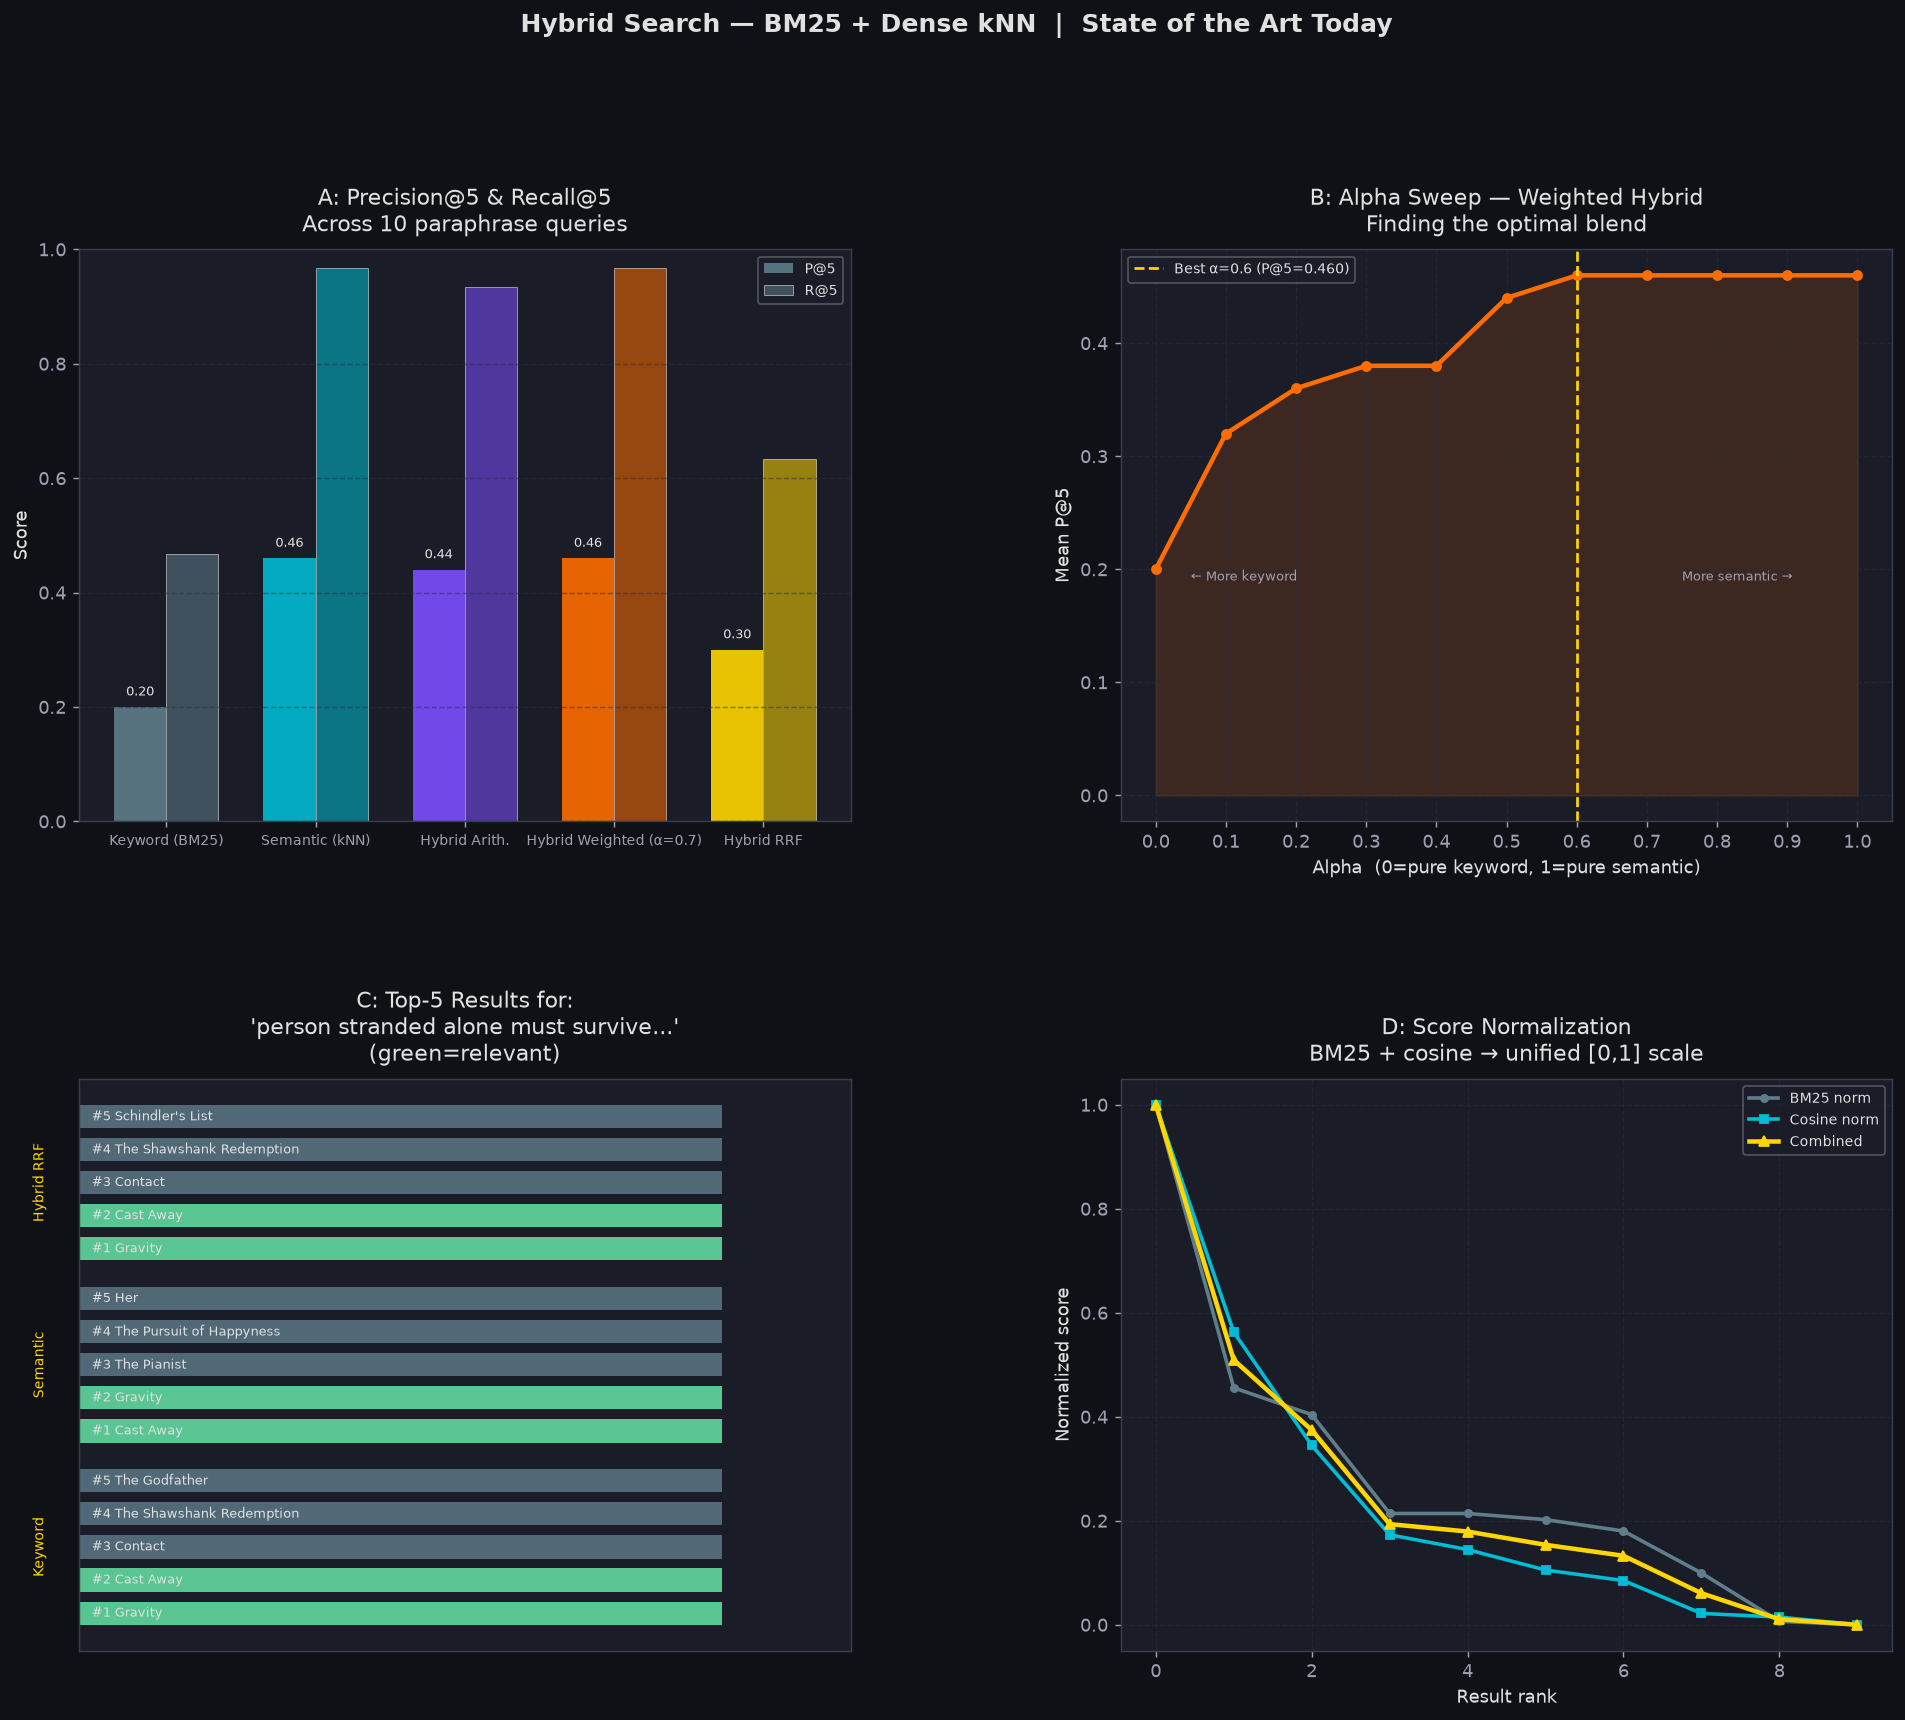

Saved: 03_hybrid_search.png


In [10]:
method_names_clean = [m.replace("\n", " ") for m in METHODS.keys()]
p5_means = [np.mean(results_table[m]["p5"]) for m in METHODS]
r5_means = [np.mean(results_table[m]["r5"]) for m in METHODS]

palette = ["#607D8B", "#00BCD4", "#7C4DFF", "#FF6D00", "#FFD600"]

fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)

# ─── Plot A: P@5 and R@5 bar chart ───────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
x = np.arange(len(method_names_clean))
w = 0.35
bars1 = ax_a.bar(x - w/2, p5_means, w, color=palette, alpha=0.9, label="P@5")
bars2 = ax_a.bar(x + w/2, r5_means, w, color=palette, alpha=0.55, label="R@5", edgecolor="white", linewidth=0.5)
ax_a.set_xticks(x)
ax_a.set_xticklabels(method_names_clean, fontsize=8, ha="center")
ax_a.set_ylim(0, 1.0)
ax_a.set_ylabel("Score")
ax_a.set_title("A: Precision@5 & Recall@5\nAcross 10 paraphrase queries", pad=10)
ax_a.legend(framealpha=0.3, fontsize=8)
ax_a.grid(axis="y")
for b, v in zip(bars1, p5_means):
    ax_a.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=7)

# ─── Plot B: Alpha sweep curve ────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(alphas, alpha_p5, color="#FF6D00", linewidth=2.5, marker="o", markersize=5)
ax_b.fill_between(alphas, alpha_p5, alpha=0.15, color="#FF6D00")
ax_b.axvline(best_alpha, color="#FFD600", linestyle="--", linewidth=1.5,
             label=f"Best α={best_alpha} (P@5={max(alpha_p5):.3f})")
ax_b.set_xlabel("Alpha  (0=pure keyword, 1=pure semantic)")
ax_b.set_ylabel("Mean P@5")
ax_b.set_title("B: Alpha Sweep — Weighted Hybrid\nFinding the optimal blend", pad=10)
ax_b.legend(framealpha=0.3, fontsize=8)
ax_b.grid(True)
ax_b.set_xticks(alphas)
ax_b.annotate("← More keyword", xy=(0.05, min(alpha_p5)-0.01), fontsize=7, color="#a0a0b0")
ax_b.annotate("More semantic →", xy=(0.75, min(alpha_p5)-0.01), fontsize=7, color="#a0a0b0")

# ─── Plot C: Top-5 results for one query across methods ──────────────────────
ax_c = fig.add_subplot(gs[1, 0])
demo_query = EVAL_SET[2]["query"]  # "person stranded alone must survive"
demo_relevant = EVAL_SET[2]["relevant"]
method_results = {
    "Keyword": keyword_search(demo_query, 5),
    "Semantic": semantic_search(demo_query, 5),
    "Hybrid RRF": hybrid_rrf(demo_query, 5),
}
y_pos = 0
ytick_pos, ytick_labels = [], []
for method, res in method_results.items():
    for rank, (doc_id, score, doc) in enumerate(res):
        color = "#69F0AE" if doc_id in demo_relevant else "#607D8B"
        ax_c.barh(y_pos, 1, color=color, alpha=0.8, height=0.7)
        ax_c.text(0.02, y_pos, f"#{rank+1} {doc['title'][:28]}", va="center", fontsize=7)
        ytick_pos.append(y_pos)
        ytick_labels.append("")
        y_pos += 1
    y_pos += 0.5  # gap between methods

# Method labels
for i, method in enumerate(["Keyword", "Semantic", "Hybrid RRF"]):
    ax_c.text(-0.05, i * 5.5 + 2, method, va="center", ha="right", fontsize=8,
              color="#FFD600", rotation=90)
ax_c.set_xlim(0, 1.2)
ax_c.set_yticks([])
ax_c.set_xticks([])
ax_c.set_title(f"C: Top-5 Results for:\n'{demo_query[:45]}...'\n(green=relevant)", pad=10)

# ─── Plot D: Score normalization visualization ────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
demo_q2 = EVAL_SET[6]["query"]  # space exploration
kw_res  = keyword_search(demo_q2, 10)
sem_res = semantic_search(demo_q2, 10)

kw_scores_raw  = [r[1] for r in kw_res]
sem_scores_raw = [r[1] for r in sem_res]
kw_norm  = _minmax(kw_scores_raw)
sem_norm = _minmax(sem_scores_raw)
combined = [(k + s) / 2 for k, s in zip(kw_norm[:min(len(kw_norm), len(sem_norm))],
                                          sem_norm[:min(len(kw_norm), len(sem_norm))])]

xs = range(min(len(kw_norm), len(sem_norm), len(combined)))
ax_d.plot(xs, kw_norm[:len(xs)],  marker="o", color="#607D8B", label="BM25 norm",  linewidth=2, markersize=4)
ax_d.plot(xs, sem_norm[:len(xs)], marker="s", color="#00BCD4", label="Cosine norm", linewidth=2, markersize=4)
ax_d.plot(xs, combined[:len(xs)], marker="^", color="#FFD600", label="Combined",    linewidth=2.5, markersize=5)
ax_d.set_xlabel("Result rank")
ax_d.set_ylabel("Normalized score")
ax_d.set_title("D: Score Normalization\nBM25 + cosine → unified [0,1] scale", pad=10)
ax_d.legend(framealpha=0.3, fontsize=8)
ax_d.grid(True)

fig.suptitle("Hybrid Search — BM25 + Dense kNN  |  State of the Art Today",
             fontsize=14, y=1.01, fontweight="bold")

plt.savefig("03_hybrid_search.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 03_hybrid_search.png")

## Step 9 — Detailed Per-Query Analysis

In [11]:
print("Per-query P@5 breakdown:\n")
print(f"{'Query':<45} {'KW':>6} {'SEM':>6} {'ARR':>6} {'WGT':>6} {'RRF':>6}")
print("-" * 73)

for ev in EVAL_SET:
    q, rel = ev["query"], ev["relevant"]
    kw_r   = keyword_search(q, 5)
    sem_r  = semantic_search(q, 5)
    arr_r  = hybrid_arithmetic(q, 5)
    wgt_r  = hybrid_weighted(q, 5, alpha=best_alpha)
    rrf_r  = hybrid_rrf(q, 5)
    scores = [precision_at_k(r, rel, 5) for r in [kw_r, sem_r, arr_r, wgt_r, rrf_r]]
    best = max(scores)
    row = [f"{s:.2f}" + (" ★" if s == best else "  ") for s in scores]
    print(f"{q[:44]:<45} {'  '.join(row)}")

Per-query P@5 breakdown:

Query                                             KW    SEM    ARR    WGT    RRF
-------------------------------------------------------------------------


man wrongly imprisoned finds hope and friend  0.20 ★  0.20 ★  0.20 ★  0.20 ★  0.20 ★


artificial intelligence becomes self-aware    0.20    0.60 ★  0.60 ★  0.60 ★  0.40  


person stranded alone must survive            0.40 ★  0.40 ★  0.40 ★  0.40 ★  0.40 ★


family drama involving inheritance and power  0.00    0.40 ★  0.40 ★  0.40 ★  0.00  


...

undercover investigation in criminal organiz  0.40    0.60 ★  0.40    0.60 ★  0.60 ★


space exploration and contact with unknown    0.20    0.60 ★  0.60 ★  0.60 ★  0.40  


animated movie about emotions and growing up  0.20    0.40 ★  0.40 ★  0.40 ★  0.40 ★


Holocaust and World War II survivor story     0.20    0.40 ★  0.40 ★  0.40 ★  0.20  


romantic relationship with unusual circumsta  0.20    0.40 ★  0.40 ★  0.40 ★  0.20  


---
## NVIDIA Perspective — Hybrid Search

### Official NVIDIA x Qdrant GPU-accelerated hybrid search partnership

> NVIDIA and Qdrant officially collaborate to deliver GPU-accelerated vector database performance.  
> Qdrant hybrid search (sparse + dense + RRF) runs on a **cuVS GPU backend** in this partnership.

### NVIDIA's hybrid pipeline

```
Query
  |-- BM25 (sparse lexical)   --|
  |-- Dense kNN (cuVS CAGRA) --|--> Score fusion (RRF) --> NIM Reranker --> Final result
                                     (Qdrant native)       (llama-nemotron-rerank)
```

### NIM Reranker — second stage after fusion
- Model: `llama-nemotron-rerank-vl-1b-v2`
- Takes top-N fused results -> re-scores -> re-ranked list
- TensorRT-LLM optimised, deployed as NIM microservice

### CAGRA filtered search (pre-filtering in hybrid)
- Achieves high recall even when 99% of vectors are filtered out
- Enables metadata + semantic + keyword hybrid at GPU speed

**References:**
- [NVIDIA x Qdrant Partnership](https://developer.nvidia.com/blog/nvidia-and-qdrant-collaborate-to-deliver-more-efficient-vector-database-performance/)
- [RAG 101: Retrieval Strategies](https://developer.nvidia.com/blog/rag-101-demystifying-retrieval-augmented-generation-pipelines/)
- [Optimizing Vector Search with cuVS](https://developer.nvidia.com/blog/optimizing-vector-search-for-indexing-and-real-time-retrieval-with-nvidia-cuvs/)


## Cleanup

In [12]:
qc.delete_collection(COLLECTION)
print(f"Collection '{COLLECTION}' deleted.")

Collection 'hybrid_search_demo' deleted.


## Summary

| Fusion Strategy | Pros | Cons |
|----------------|------|------|
| **Arithmetic Mean** | Simple, no tuning needed | Equal weight may not fit all domains |
| **Weighted Sum (α)** | Tunable to domain | Requires labeled data to pick best α |
| **RRF** | Parameter-free, robust, no score calibration needed | Ignores score magnitudes |

**Key takeaways from the AWS slide deck:**
- Hybrid consistently outperforms either keyword or semantic alone
- RRF is a strong default when you don't have labels to tune α
- Min-max normalization is critical before combining BM25 and cosine scores (they live on different scales)
- Harmonic mean (not shown here) penalizes large discrepancies — good when you want both signals to agree